
---
date: "2026-08-16"
date-modified: last-modified
format:
  html:
    toc: true
---


# Foundations of Stochastic Processes

A **[stochastic process](stochastic-processes-foundations.ipynb)** is a mathematical model for a system or quantity that evolves randomly over time. In financial mathematics, stochastic processes form the essential toolkit for modeling asset prices, interest rates, high-frequency order arrivals, credit rating migrations, and pricing complex financial derivatives.

---


## 1\. Motivation: Financial Modeling and Stochastic Calculus

The primary motivation for stochastic calculus in finance is **derivative pricing** (options, futures, fixed-income derivatives):

- **The Black-Scholes-Merton Model:** The landmark option pricing framework developed by Fischer Black, Myron Scholes, and Robert Merton (honored with the 1997 Nobel Prize in Economics).
- **Modeling Objective:** Model the price of an underlying asset over time. The canonical model is **Geometric Brownian Motion (GBM)**.
- **Analytical Tools:** Stochastic analysis and **Itô calculus** (founded by Kiyosi Itô), which provides the mathematical rules for integrating and differentiating functions of random continuous paths.


## 2\. State Space and Motivating Financial Examples

A process at any instant $t$ maps an underlying random outcome $\omega$ to a value $X_t(\omega) \in \mathcal{S}$, called the **state** of the system (a term originating in physics and engineering).

::: {#def-state-space}
## State Space
The **state space** $\mathcal{S}$ is the set of all possible values that $X_t$ can take:

- **Discrete State Space:** $\mathcal{S}$ is finite or countable (e.g., $\mathcal{S} = \{1, 2, \dots, K\}$ or $\mathbb{Z}$).
- **Continuous State Space:** $\mathcal{S}$ is continuous (e.g., $\mathcal{S} = \mathbb{R}$ or $\mathcal{S} = (0, \infty)$).
:::

### 2.1\. Example: Regime Switching Models (Hidden Markov Models)

Financial markets frequently transition between distinct macroeconomic states or **regimes**:

- **Market Direction:** *Bullish* (upward trend) vs. *Bearish* (downward trend).
- **Volatility Level:** *High Volatility* (market stress/crisis) vs. *Low Volatility* (calm market).

In a regime-switching diffusion, a discrete Markov chain switches the drift and volatility parameters of a continuous Brownian motion ($dX_t = \mu(S_t) dt + \sigma(S_t) dW_t$).

### 2.2\. Example: Corporate Credit Rating Migrations

Credit rating agencies assign credit quality categories to companies:
$$
\text{AAA} \longrightarrow \text{AA} \longrightarrow \text{A} \longrightarrow \text{BBB} \longrightarrow \text{BB} \longrightarrow \text{B} \longrightarrow \text{CCC} \longrightarrow \text{D (Default)}
$$
The migration of a firm across these discrete rating states is modeled as a **Markov chain**, where default ($\text{D}$) is an absorbing state.

### 2.3\. Example: Market Microstructure and Order Books

In high-frequency market microstructure, trades and orders arrive in continuous time:

- **Key Questions:** When do new buyers and sellers arrive? What limit prices do they post? What is the matching transaction price?
- **Multiple Stochastic Processes:**
  - Number of arriving orders: modeled as a Poisson process $(N_t)_{t \ge 0}$.
  - Order prices and matching prices: modeled as random marks attached to each arrival epoch.


## 3\. Definition of a Stochastic Process

We now give the formal mathematical definition of a stochastic process.

::: {#def-stochastic-process}
## Stochastic Process
A **stochastic process** is a collection of [random variables](random-variables.ipynb) defined on a common [probability space](probability.ipynb) $(\Omega, \mathcal{F}, \mathbb{P})$ and indexed by a parameter set $T$ (time):
$$
\left( X_t, \, t \in T \right) = \left( X_t(\omega), \, t \in T, \, \omega \in \Omega \right)
$$
:::

::: {.callout-note}
## Dual Perspective: Scenario $\omega$ vs. Time $t$
The quantity $X_t(\omega)$ is a function of two variables:

1. **Fixed $t \in T$:** $\omega \mapsto X_t(\omega)$ is a standard [random variable](random-variables.ipynb) describing the state across all possible scenarios $\omega \in \Omega$ at time $t$.
2. **Fixed $\omega \in \Omega$:** $t \mapsto X_t(\omega)$ is a deterministic curve as a function of time $t$, called a **sample path**, **trajectory**, or **realization** of the process.
:::


## 4\. Time Domains and Time Series

The parameter set $T$ represents the time horizon over which the process is observed.

### 4.1\. Discrete Time

- $T = \mathbb{N}_0 = \{0, 1, 2, \dots\}$ or $T = \mathbb{Z} = \{\dots, -1, 0, 1, \dots\}$.

::: {#def-time-series}
## Time Series
A **time series** $X_t$ is a discrete-time stochastic process with index set $t \in \mathbb{Z}$:
$$
\left( X_t \right)_{t \in \mathbb{Z}}
$$
:::

### 4.2\. Continuous Time

- **Infinite Horizon:** $t \in [0, \infty)$, representing perpetual models.
- **Finite Horizon:** $t \in [0, T]$, where $T > 0$ represents a deadline, fixed investment horizon, or option maturity.


## 5\. Finite-Dimensional Distributions (Fidis)

To describe the joint probabilistic behavior of a stochastic process across multiple time points, we use finite-dimensional vectors.

::: {#def-fidis}
## Finite-Dimensional Distribution (Fidi)
For any choice of finite time points $t_1, t_2, \dots, t_n \in T$ with $n \ge 1$, the joint distribution of the random vector:
$$
\left( X_{t_1}, X_{t_2}, \dots, X_{t_n} \right)
$$
is called a **finite-dimensional distribution (fidi)** of the process $(X_t)_{t \in T}$.
:::

::: {.callout-note}
## Intuition: The Complexity of Fidis
In general, it sounds hard to specify an arbitrary stochastic process using its fidis, because one must specify consistent joint distributions for every possible choice of $(t_1, \dots, t_n)$ for all $n \ge 1$.

However, there is an extraordinarily important class of processes where this specification becomes remarkably simple: **Gaussian Processes**.
:::


## 6\. Gaussian Processes and Covariance Functions

**[Brownian motion](gaussian-processes.ipynb)** belongs to the fundamental family of Gaussian processes.

::: {#def-gaussian-process}
## Gaussian Process
A stochastic process $(X_t)_{t \in T}$ is a **Gaussian process** if every finite-dimensional distribution is [multivariate normal (Gaussian)](multivariate-normal-distribution.ipynb).
:::

Because any multivariate normal distribution is completely determined by its mean vector and covariance matrix, to introduce a Gaussian process it is enough to specify two functions:

1. **Mean Function:** $\mu_X(t) = \mathbb{E}(X_t)$ for all $t \in T$.
2. **Covariance Function:** $C_X(t, s) = \text{Cov}(X_s, X_t)$ for all $s, t \in T$.

::: {#prp-white-noise-example}
## Example: Continuous-Time i.i.d. Standard Normal Process
Let $T = [0, 1]$ and suppose $X_t \stackrel{i.i.d.}{\sim} \mathcal{N}(0, 1)$ for every $t \in [0, 1]$.

Its mean and covariance functions are:
$$
\mu(t) = 0, \qquad C(t, s) = \begin{cases} 1, & s = t \\ 0, & s \ne t \end{cases}
$$
Because the values at distinct times $s \ne t$ are completely uncorrelated and independent, the sample paths $t \mapsto X_t(\omega)$ are extremely erratic and nowhere continuous, oscillating violently within the $\pm 2$ standard deviation boundary.
:::


## 7\. Python Simulation: Sample Paths, White Noise, and Regimes

Below, we simulate sample path realizations of continuous Brownian motion, the erratic continuous i.i.d. normal white noise, and a regime-switching process.

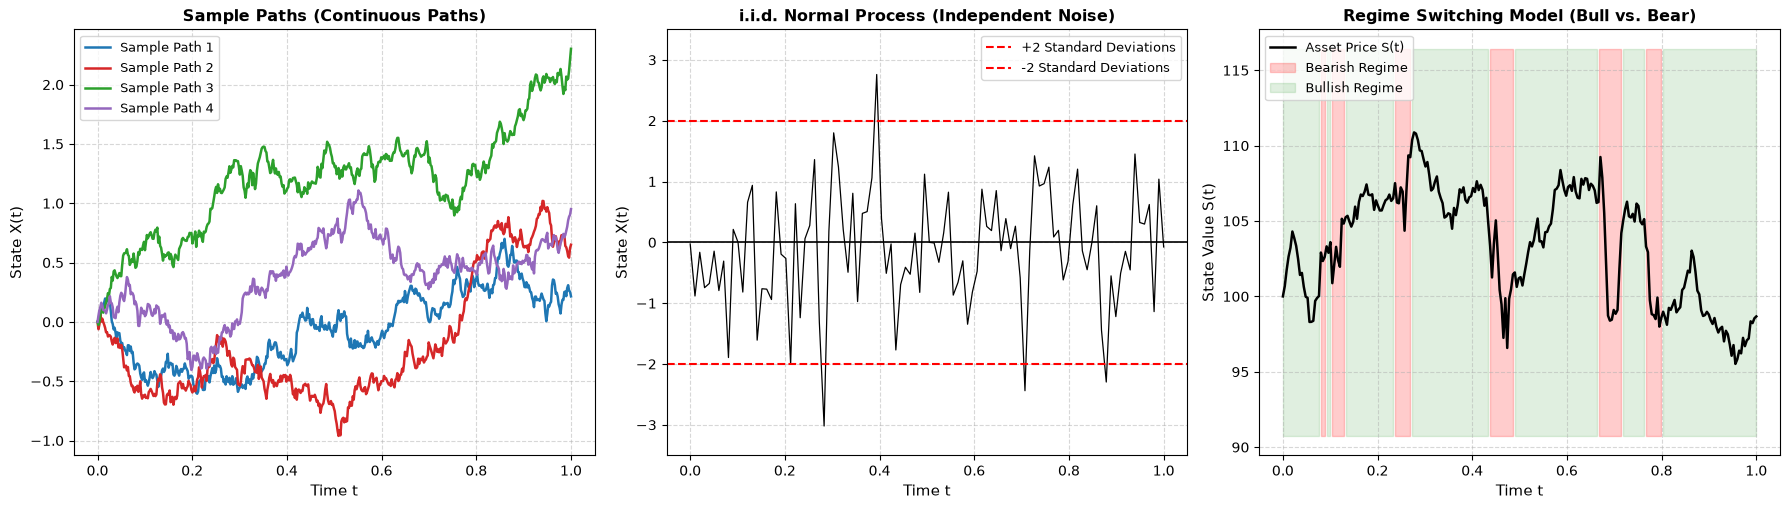

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# 1. Continuous Sample Paths: Brownian Motion Realizations
T_max = 1.0
N = 500
time_grid = np.linspace(0.0, T_max, N)
dt = T_max / (N - 1)

colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
for i in range(4):
    path = np.zeros(N)
    path[1:] = np.cumsum(np.random.normal(0, np.sqrt(dt), N - 1))
    axes[0].plot(time_grid, path, lw=1.8, color=colors[i], label=f'Sample Path {i+1}')

axes[0].set_title('Sample Paths (Continuous Paths)', fontsize=11.5, fontweight='bold')
axes[0].set_xlabel('Time t', fontsize=10.5)
axes[0].set_ylabel('State X(t)', fontsize=10.5)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left', fontsize=9)

# 2. Continuous i.i.d. Normal Process (Erratic White Noise)
white_noise = np.random.normal(0, 1, 100)
wn_time = np.linspace(0, 1, 100)
axes[1].plot(wn_time, white_noise, color='black', lw=0.9)
axes[1].axhline(0, color='black', lw=1.2)
axes[1].axhline(2, color='red', linestyle='--', lw=1.5, label='+2 Standard Deviations')
axes[1].axhline(-2, color='red', linestyle='--', lw=1.5, label='-2 Standard Deviations')
axes[1].set_title('i.i.d. Normal Process (Independent Noise)', fontsize=11.5, fontweight='bold')
axes[1].set_xlabel('Time t', fontsize=10.5)
axes[1].set_ylabel('State X(t)', fontsize=10.5)
axes[1].set_ylim([-3.5, 3.5])
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right', fontsize=9)

# 3. Regime Switching: Bullish vs Bearish States
n_steps = 250
regimes = np.zeros(n_steps, dtype=int)
gbm_path = np.zeros(n_steps)
gbm_path[0] = 100.0
curr_reg = 0
mu_reg = [0.15, -0.20]
sig_reg = [0.10, 0.30]
P_trans = [[0.97, 0.03], [0.06, 0.94]]
dt_r = 1.0 / n_steps

for t in range(1, n_steps):
    curr_reg = np.random.choice([0, 1], p=P_trans[curr_reg])
    regimes[t] = curr_reg
    dW = np.random.normal(0, np.sqrt(dt_r))
    gbm_path[t] = gbm_path[t-1] * np.exp((mu_reg[curr_reg] - 0.5 * sig_reg[curr_reg]**2) * dt_r + sig_reg[curr_reg] * dW)

t_axis = np.linspace(0, 1, n_steps)
axes[2].plot(t_axis, gbm_path, color='black', lw=1.8, label='Asset Price S(t)')
axes[2].fill_between(t_axis, gbm_path.min() * 0.95, gbm_path.max() * 1.05, 
                     where=(regimes == 1), color='red', alpha=0.2, label='Bearish Regime')
axes[2].fill_between(t_axis, gbm_path.min() * 0.95, gbm_path.max() * 1.05, 
                     where=(regimes == 0), color='green', alpha=0.12, label='Bullish Regime')
axes[2].set_title('Regime Switching Model (Bull vs. Bear)', fontsize=11.5, fontweight='bold')
axes[2].set_xlabel('Time t', fontsize=10.5)
axes[2].set_ylabel('State Value S(t)', fontsize=10.5)
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
